# CSCI 347 - Data Mining Final Project
## Predicting Credit Card Default Risk Using Classification Models
### Ryan Adolph, Braeden Olds, Michael Oswald

**Dataset:** Default of Credit Card Clients, UCI Machine Learning Repository  
**Citation:** Yeh, I. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H

## 1. Problem Overview

The goal of this project is to predict whether a credit card client will default on their payment the following month. This is a supervised binary classification problem.

- Target class `0`: client does not default
- Target class `1`: client defaults

## 2. Stakeholders and Value

**Stakeholders:** banks, credit card companies, financial analysts, risk teams, and customers.

**Project value:** compare classification methods for predicting default risk and identify patterns that may help explain which financial behaviors are associated with higher default risk.

**Ethical note:** credit risk models can affect real people, so the final discussion should acknowledge fairness concerns, especially around demographic features.

## 3. Setup and Imports

In [2]:
# Run this cell before the imports to install packages into the active Jupyter kernel.
%pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 4. Load Dataset

Load the Default of Credit Card Clients dataset from the UCI Machine Learning Repository. Confirm the feature matrix, target variable, and dataset metadata.

In [4]:
# Load the dataset from UCI.
default_credit = fetch_ucirepo(id=350)

X = default_credit.data.features.copy()
y = default_credit.data.targets.copy()

# Rename the UCI X1-X23 columns to the dataset's descriptive feature names.
feature_names = default_credit.variables.loc[
    default_credit.variables["role"] == "Feature", ["name", "description"]
]
rename_map = dict(zip(feature_names["name"], feature_names["description"]))
X = X.rename(columns=rename_map)

# Convert the target from a one-column DataFrame to a clearly named Series.
y = y.squeeze().rename("default_next_month")

# Keep a combined DataFrame available for inspection and later EDA.
df = X.copy()
df[y.name] = y

print(default_credit.metadata["name"])
print("Dataset DOI:", default_credit.metadata["dataset_doi"])
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(default_credit.variables)

Default of Credit Card Clients
Dataset DOI: 10.24432/C55S3H
Feature matrix shape: (30000, 23)
Target shape: (30000,)


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,X1,Feature,Integer,None,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,None,PAY_0,None,no
7,X7,Feature,Integer,None,PAY_2,None,no
8,X8,Feature,Integer,None,PAY_3,None,no
9,X9,Feature,Integer,None,PAY_4,None,no


## 5. Dataset Summary and Initial Inspection

This section documents the dataset shape, column names, data types, missing values, duplicate rows, and class balance.

In [5]:
# Inspect dataset shape, feature columns, target column, and data types.
dataset_summary = pd.DataFrame({
    "item": ["Rows", "Input features", "Target column"],
    "value": [df.shape[0], X.shape[1], y.name],
})

display(dataset_summary)
display(X.head())

data_types = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
})
display(data_types)

,item,value
0,Rows,30000
1,Input features,23
2,Target column,default_next_month


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


,column,dtype
0,LIMIT_BAL,int64
1,SEX,int64
2,EDUCATION,int64
3,MARRIAGE,int64
4,AGE,int64
5,PAY_0,int64
6,PAY_2,int64
7,PAY_3,int64
8,PAY_4,int64
9,PAY_5,int64


In [6]:
# Check missing values and duplicate rows.
missing_values = df.isna().sum().sort_values(ascending=False)
missing_table = missing_values.reset_index()
missing_table.columns = ["column", "missing_count"]
missing_table["missing_percent"] = (missing_table["missing_count"] / len(df) * 100).round(2)

duplicate_count = df.duplicated().sum()

display(missing_table)
print("Duplicate rows:", duplicate_count)

,column,missing_count,missing_percent
0,LIMIT_BAL,0,0.0
1,SEX,0,0.0
2,EDUCATION,0,0.0
3,MARRIAGE,0,0.0
4,AGE,0,0.0
5,PAY_0,0,0.0
6,PAY_2,0,0.0
7,PAY_3,0,0.0
8,PAY_4,0,0.0
9,PAY_5,0,0.0


Duplicate rows: 35


,default_next_month,count,percent
0,0,23364,77.88
1,1,6636,22.12


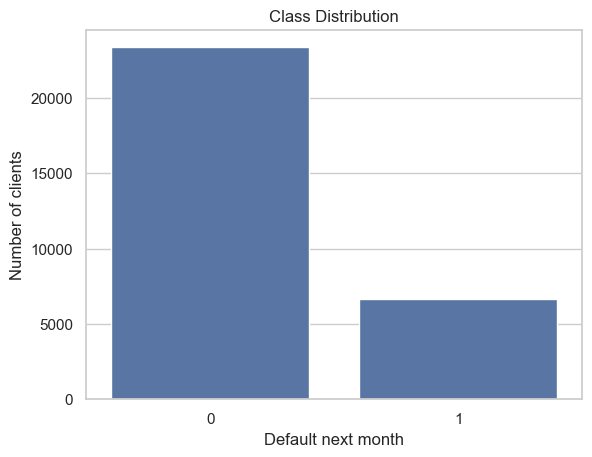

In [7]:
# Inspect class balance for default vs non-default clients.
class_counts = y.value_counts().sort_index()
class_balance = pd.DataFrame({
    "default_next_month": class_counts.index,
    "count": class_counts.values,
    "percent": (class_counts.values / len(y) * 100).round(2),
})

display(class_balance)

ax = sns.barplot(data=class_balance, x="default_next_month", y="count")
ax.set_title("Class Distribution")
ax.set_xlabel("Default next month")
ax.set_ylabel("Number of clients")
plt.show()

## 6. Exploratory Data Analysis

Recommended visuals for this section

- Class balance bar chart
- Age distribution histogram
- Credit limit histogram
- Correlation heatmap
- Boxplots comparing key variables by default status
- Payment history variables compared with default status

In [8]:
# Summary statistics for the numerical features.
summary_stats = X.describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


,default_next_month,count,percent
0,No Default,23364,77.88
1,Default,6636,22.12


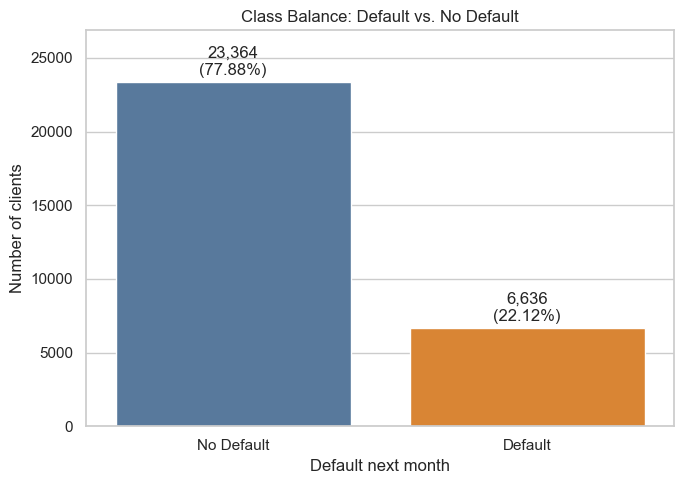

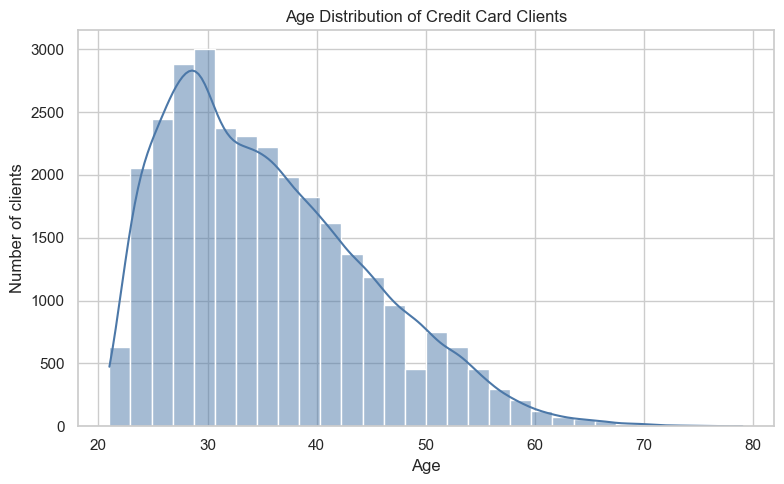

In [9]:
# Class balance bar chart.
class_counts = y.value_counts().sort_index()
class_balance = pd.DataFrame({
    "default_next_month": class_counts.index.map({0: "No Default", 1: "Default"}),
    "count": class_counts.values,
    "percent": (class_counts.values / len(y) * 100).round(2),
})

display(class_balance)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=class_balance,
    x="default_next_month",
    y="count",
    hue="default_next_month",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)

for index, row in class_balance.iterrows():
    ax.text(
        index,
        row["count"] + 300,
        f"{row['count']:,}\n({row['percent']}%)",
        ha="center",
        va="bottom",
    )

ax.set_title("Class Balance: Default vs. No Default")
ax.set_xlabel("Default next month")
ax.set_ylabel("Number of clients")
plt.ylim(0, class_balance["count"].max() * 1.15)
plt.tight_layout()
plt.show()

# Age distribution histogram.
plt.figure(figsize=(8, 5))
sns.histplot(data=X, x="AGE", bins=30, kde=True, color="#4C78A8")
plt.title("Age Distribution of Credit Card Clients")
plt.xlabel("Age")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

**Class balance and age distribution notes:** The class balance chart shows that non-default clients make up the majority of the dataset, while default clients are the minority class. This means accuracy by itself can be misleading because a model can score fairly well by mostly predicting the majority class. The age histogram shows that most clients are concentrated in the younger-to-middle adult range, with fewer clients at older ages.

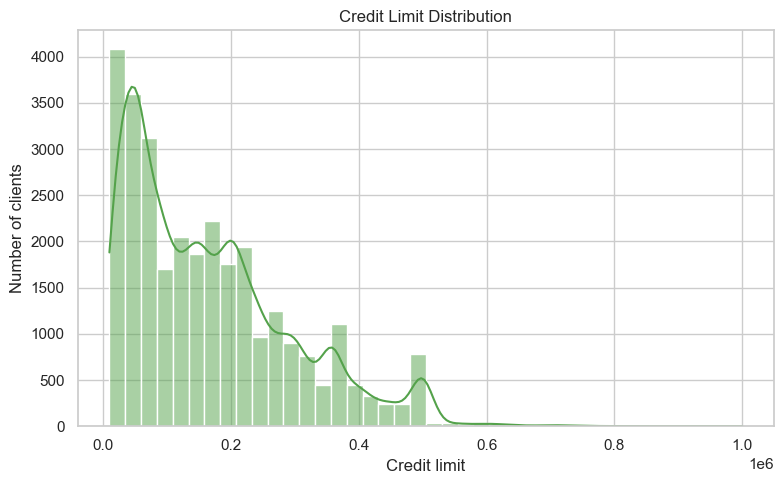

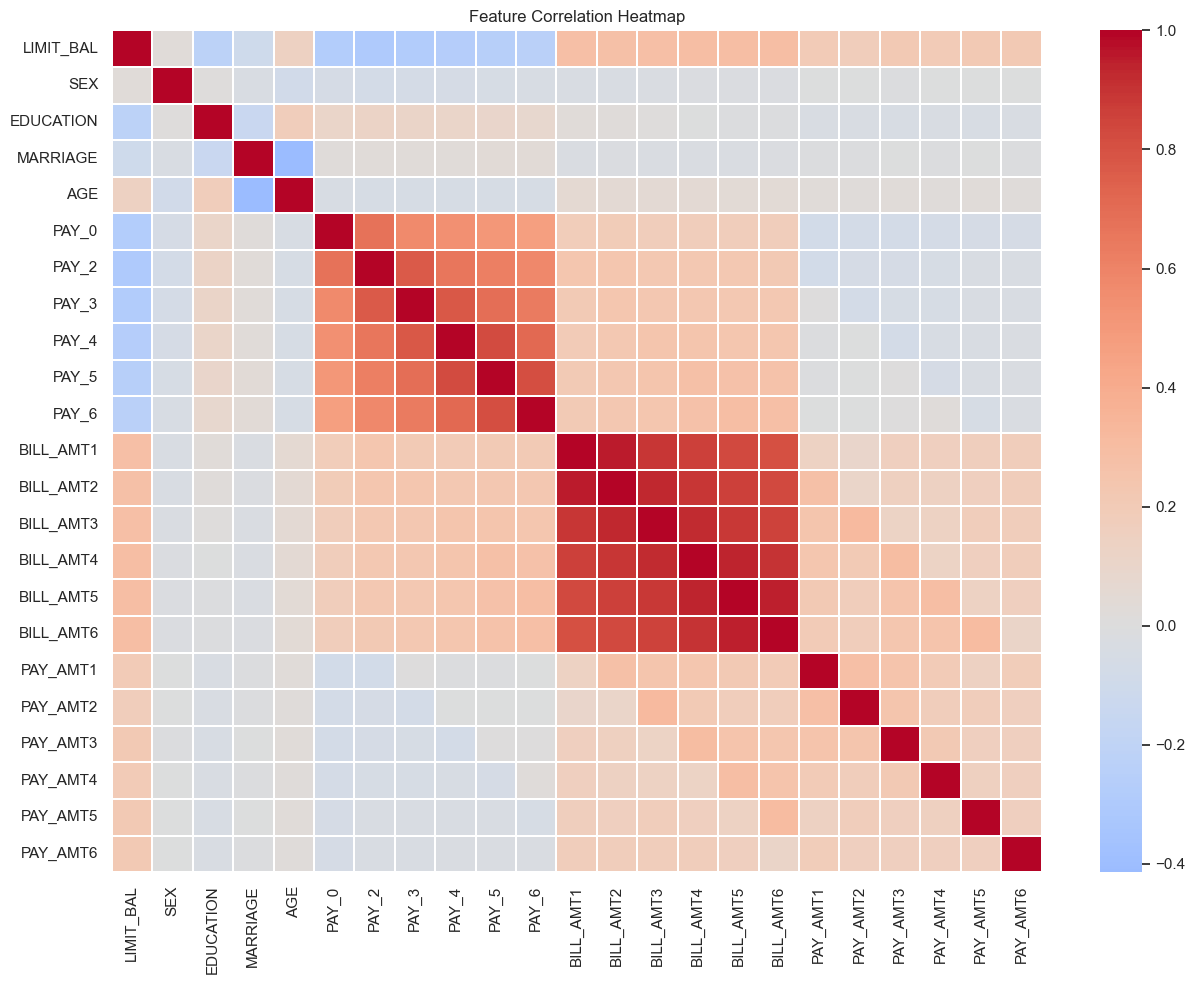

In [10]:
# Credit limit distribution histogram.
plt.figure(figsize=(8, 5))
sns.histplot(data=X, x="LIMIT_BAL", bins=40, kde=True, color="#54A24B")
plt.title("Credit Limit Distribution")
plt.xlabel("Credit limit")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

# Correlation heatmap for numerical features.
plt.figure(figsize=(13, 10))
correlation_matrix = X.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.25)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Credit limit and correlation notes:** The credit limit distribution is right-skewed, meaning many clients have lower or moderate limits while fewer clients have very high limits. The correlation heatmap helps show relationships between billing amounts, payment amounts, repayment status variables, and other numeric features. Groups of bill amount variables tend to be related to each other because they describe balances across nearby months.

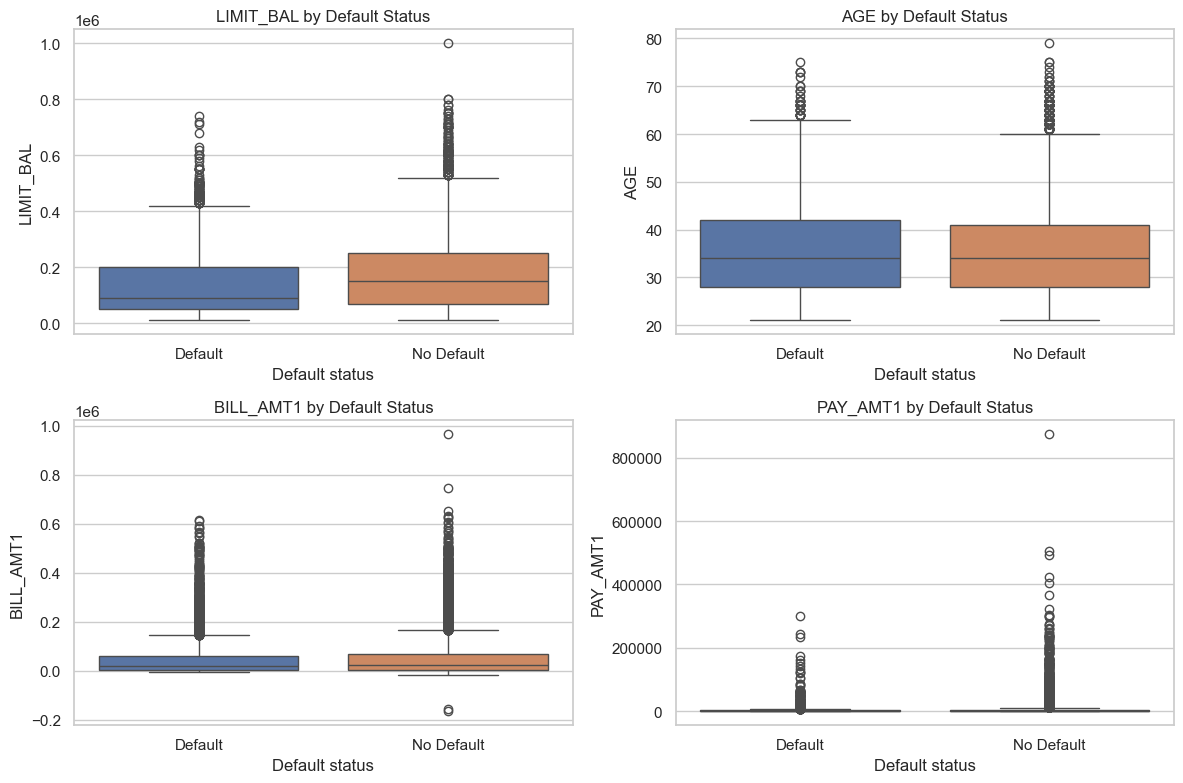

default_label,Default,No Default
PAY_0,0.668174,-0.211222
PAY_2,0.458258,-0.301917
PAY_3,0.362116,-0.316256
PAY_4,0.254521,-0.355633
PAY_5,0.167872,-0.389488
PAY_6,0.112116,-0.405624


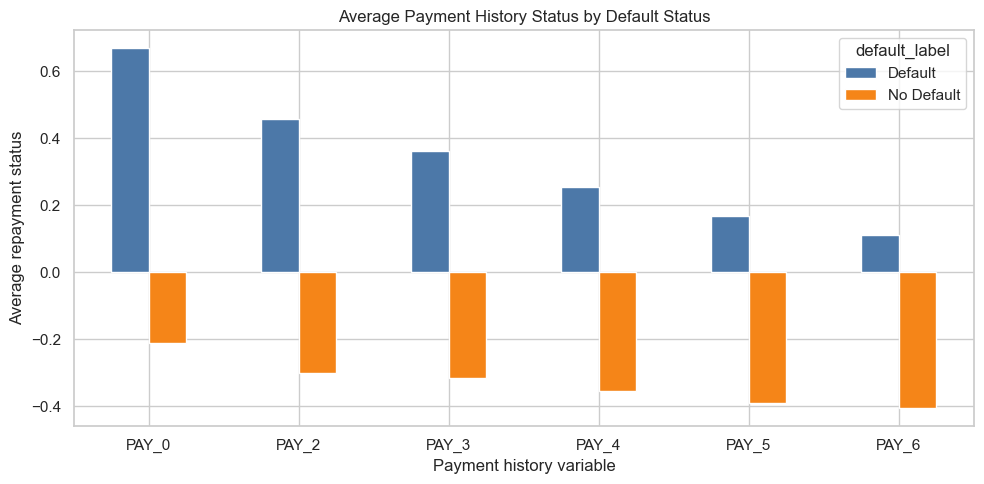

In [11]:
# Boxplots comparing selected variables by default status.
plot_df = df.copy()
plot_df["default_label"] = plot_df["default_next_month"].map({0: "No Default", 1: "Default"})

boxplot_features = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, boxplot_features):
    sns.boxplot(data=plot_df, x="default_label", y=feature, hue="default_label", ax=ax, legend=False)
    ax.set_title(f"{feature} by Default Status")
    ax.set_xlabel("Default status")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

# Payment history comparison by default status.
payment_history_features = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
payment_history_means = plot_df.groupby("default_label")[payment_history_features].mean().T

display(payment_history_means)

payment_history_means.plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#F58518"])
plt.title("Average Payment History Status by Default Status")
plt.xlabel("Payment history variable")
plt.ylabel("Average repayment status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Boxplot and payment history notes:** The boxplots compare selected financial variables between clients who defaulted and clients who did not default. The payment history comparison is especially important because clients who default tend to have worse recent repayment status values. This supports the idea that recent payment delays are strong indicators of default risk.

## 7. Cleaning and Preprocessing Plan

Preprocessing should handle missing values, categorical variables, and scaling. Use `Pipeline` and `ColumnTransformer` so preprocessing is applied correctly inside cross-validation.

**Categorical features to one-hot encode:** `SEX`, `EDUCATION`, and `MARRIAGE` are stored as numbers, but the numbers are category labels rather than true continuous measurements. One-hot encoding avoids treating these labels as ordered quantities.

**Features that need scaling:** Logistic Regression and KNN are affected by feature magnitude, so the numeric variables are scaled for those models.

**Tree-based models:** Decision Tree, Random Forest, and Gradient Boosting split on feature thresholds, so they do not require feature scaling. The notebook keeps a separate tree preprocessing pipeline for those models.

In [12]:
# Define feature groups for preprocessing.
# SEX, EDUCATION, and MARRIAGE are numeric codes, but they represent categories.
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numerical_features = [col for col in X.columns if col not in categorical_features]

feature_groups = pd.DataFrame({
    "feature_group": ["Categorical", "Numerical"],
    "columns": [", ".join(categorical_features), ", ".join(numerical_features)],
    "count": [len(categorical_features), len(numerical_features)],
})

display(feature_groups)

,feature_group,columns,count
0,Categorical,"SEX, EDUCATION, MARRIAGE",3
1,Numerical,"LIMIT_BAL, AGE, PAY_0, PAY_2, PAY_3, PAY_4, PA...",20


In [13]:
# Build preprocessing transformers.
# The scaled preprocessor is useful for Logistic Regression, KNN, SVM, and similar models.
numeric_scaled_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# The unscaled numeric preprocessor is useful for tree-based models.
numeric_unscaled_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

scaled_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_scaled_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features),
])

tree_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_unscaled_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features),
])

# Default preprocessor used by later model code when a model-specific preprocessor is not required.
preprocessor = scaled_preprocessor

print("Scaled preprocessor ready for distance/magnitude-sensitive models.")
print("Tree preprocessor ready for tree-based models.")

Scaled preprocessor ready for distance/magnitude-sensitive models.
Tree preprocessor ready for tree-based models.


## 8. Classifiers to Compare

Minimum model set from the project plan:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Gradient Boosting

Optional models if time allows:

- Naive Bayes
- Support Vector Machine
- Neural Network / Multi-layer Perceptron

In [14]:
# Define models for comparison.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    #"Naive Bayes": GaussianNB(),
    #"SVM": SVC(probability=True, random_state=RANDOM_STATE),
}

## 9. Evaluation Strategy

Use stratified k-fold cross-validation because the default class may be imbalanced. Report mean and standard deviation for each metric.

**Metrics:** accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix.

Recall and F1-score should receive extra attention because missing actual defaulters can be costly.

In [15]:
# Set up stratified k-fold cross-validation and scoring metrics.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

In [16]:
# Run cross-validation for each classifier using a pipeline.
tree_based_models = {"Decision Tree", "Random Forest", "Gradient Boosting"}

cv_results = []
for model_name, model in models.items():
    print("Running cross-validation for", model_name)
    model_preprocessor = tree_preprocessor if model_name in tree_based_models else scaled_preprocessor
    
    pipeline = Pipeline(steps=[
        ("preprocessor", model_preprocessor),
        ("model", model),
    ])
    
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=1)
    
    for metric in scoring:
        cv_results.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": scores[f"test_{metric}"].mean(),
            "Std": scores[f"test_{metric}"].std()
        })

results_long = pd.DataFrame(cv_results)
display(results_long)

results_summary = results_long.copy()
results_summary["Mean +/- Std"] = results_summary.apply(
    lambda row: f"{row['Mean']:.4f} +/- {row['Std']:.4f}", axis=1
)

comparison_table = results_summary.pivot(
    index="Model",
    columns="Metric",
    values="Mean +/- Std",
).reset_index()

comparison_table = comparison_table[["Model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
comparison_table.columns = ["Classifier", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

display(comparison_table)

Running cross-validation for Logistic Regression
Running cross-validation for Decision Tree
Running cross-validation for Random Forest
Running cross-validation for KNN
Running cross-validation for Gradient Boosting


,Model,Metric,Mean,Std
0,Logistic Regression,accuracy,0.811200,0.001756
1,Logistic Regression,precision,0.715214,0.011001
2,Logistic Regression,recall,0.243369,0.005254
3,Logistic Regression,f1,0.363151,0.007035
4,Logistic Regression,roc_auc,0.724114,0.004502
5,Decision Tree,accuracy,0.727733,0.003484
6,Decision Tree,precision,0.390348,0.007467
7,Decision Tree,recall,0.410941,0.008532
8,Decision Tree,f1,0.400376,0.007875
9,Decision Tree,roc_auc,0.614579,0.005552


,Classifier,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.7277 +/- 0.0035,0.3903 +/- 0.0075,0.4109 +/- 0.0085,0.4004 +/- 0.0079,0.6146 +/- 0.0056
1,Gradient Boosting,0.8207 +/- 0.0042,0.6754 +/- 0.0208,0.3654 +/- 0.0061,0.4742 +/- 0.0099,0.7811 +/- 0.0056
2,KNN,0.7926 +/- 0.0033,0.5485 +/- 0.0125,0.3553 +/- 0.0054,0.4312 +/- 0.0057,0.7011 +/- 0.0057
3,Logistic Regression,0.8112 +/- 0.0018,0.7152 +/- 0.0110,0.2434 +/- 0.0053,0.3632 +/- 0.0070,0.7241 +/- 0.0045
4,Random Forest,0.8162 +/- 0.0033,0.6490 +/- 0.0162,0.3693 +/- 0.0053,0.4707 +/- 0.0064,0.7658 +/- 0.0038


## 10. Model Comparison Results

The cross-validation code above creates `comparison_table`, which reports the mean +/- standard deviation for each classifier and metric.

Use the generated table to compare accuracy, precision, recall, F1-score, and ROC-AUC. The final model should be selected based on a balance of F1-score, recall, and ROC-AUC rather than accuracy alone.

## 11. Best Model Evaluation

Gradient Boosting is selected as the final model because it had the strongest overall balance of F1-score and ROC-AUC in cross-validation. This section evaluates that selected model on a final holdout test set.

In [17]:
# Holdout test evaluation for the selected model.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

best_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7800761352353489


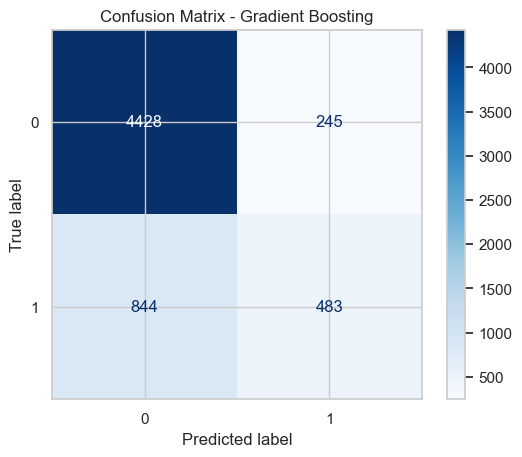

In [18]:
# Plot confusion matrix for the selected model.

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

## 12. Feature Importance and Interpretability

This section uses the selected Gradient Boosting model to identify which features contributed most to prediction. Feature importance is useful for interpretation, but it does not prove causation. It shows which variables the model relied on most when separating default and non-default clients.

,Feature,Importance
2,Payment status - most recent month,0.638704
3,Payment status - 2 months ago,0.073623
4,Payment status - 3 months ago,0.035963
8,Bill amount - most recent month,0.033648
0,Credit limit,0.028332
16,Payment amount - 3 months ago,0.022462
15,Payment amount - 2 months ago,0.021062
5,Payment status - 4 months ago,0.018289
7,Payment status - 6 months ago,0.017470
14,Payment amount - most recent month,0.017352


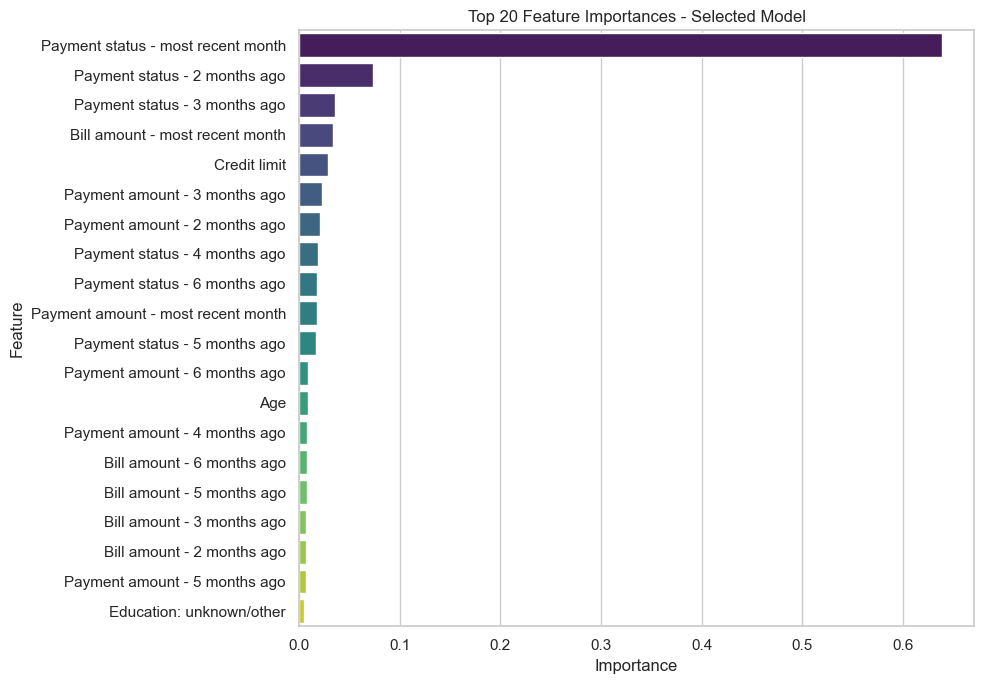

In [19]:
# Create a feature importance plot for the selected tree-based model.
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

feature_label_map = {
    "LIMIT_BAL": "Credit limit",
    "AGE": "Age",
    "PAY_0": "Payment status - most recent month",
    "PAY_2": "Payment status - 2 months ago",
    "PAY_3": "Payment status - 3 months ago",
    "PAY_4": "Payment status - 4 months ago",
    "PAY_5": "Payment status - 5 months ago",
    "PAY_6": "Payment status - 6 months ago",
    "BILL_AMT1": "Bill amount - most recent month",
    "BILL_AMT2": "Bill amount - 2 months ago",
    "BILL_AMT3": "Bill amount - 3 months ago",
    "BILL_AMT4": "Bill amount - 4 months ago",
    "BILL_AMT5": "Bill amount - 5 months ago",
    "BILL_AMT6": "Bill amount - 6 months ago",
    "PAY_AMT1": "Payment amount - most recent month",
    "PAY_AMT2": "Payment amount - 2 months ago",
    "PAY_AMT3": "Payment amount - 3 months ago",
    "PAY_AMT4": "Payment amount - 4 months ago",
    "PAY_AMT5": "Payment amount - 5 months ago",
    "PAY_AMT6": "Payment amount - 6 months ago",
    "SEX_1": "Sex: male",
    "SEX_2": "Sex: female",
    "EDUCATION_1": "Education: graduate school",
    "EDUCATION_2": "Education: university",
    "EDUCATION_3": "Education: high school",
    "EDUCATION_4": "Education: other",
    "EDUCATION_0": "Education: unknown",
    "EDUCATION_5": "Education: unknown/other",
    "EDUCATION_6": "Education: unknown/other",
    "MARRIAGE_0": "Marriage: unknown",
    "MARRIAGE_1": "Marriage: married",
    "MARRIAGE_2": "Marriage: single",
    "MARRIAGE_3": "Marriage: other",
}

def readable_feature_name(feature_name):
    cleaned_name = feature_name.replace("num__", "").replace("cat__", "")
    return feature_label_map.get(cleaned_name, cleaned_name.replace("_", " ").title())

importances_df = pd.DataFrame({
    "feature": feature_names,
    "feature_label": [readable_feature_name(name) for name in feature_names],
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

importance_display = importances_df[["feature_label", "importance"]].rename(
    columns={"feature_label": "Feature", "importance": "Importance"}
)

display(importance_display)

plt.figure(figsize=(10, 7))
sns.barplot(data=importances_df, x="importance", y="feature_label", hue="feature_label", palette="viridis", legend=False)
plt.title("Top 20 Feature Importances - Selected Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 13. Findings and Discussion

Gradient Boosting was the strongest overall model in the cross-validation results. It had the best balance of accuracy, F1-score, and ROC-AUC, with about 0.821 accuracy, 0.474 F1-score, and 0.781 ROC-AUC. Random Forest was close behind, but Gradient Boosting performed slightly better overall, so it was selected as the final model.

Accuracy was useful, but it was not enough by itself. The dataset has more non-default clients than default clients, so a model can look accurate while still missing many clients who actually default. For this reason, recall, F1-score, and ROC-AUC were more important for comparing the models. Recall matters because a false negative means the model failed to identify a client who did default.

The Decision Tree had the highest recall, at about 0.411, meaning it found the largest share of actual default cases. However, it also had weaker precision, accuracy, and ROC-AUC. In other words, it caught more defaulters but made more mistakes overall. Gradient Boosting was a better final choice because it gave a stronger balance across the evaluation metrics.

On the final holdout test set, Gradient Boosting reached about 0.82 accuracy and 0.780 ROC-AUC. For the default class, it had about 0.66 precision, 0.36 recall, and 0.47 F1-score. This shows that the model is much better at identifying non-default clients than default clients, which is a common challenge with imbalanced credit risk data.

The most important features were related to recent payment history. `PAY_0` was the strongest predictor by a large margin, followed by other repayment status variables such as `PAY_2` and `PAY_3`. This suggests that recent late-payment behavior is more useful for predicting default than demographic variables. Credit limit, bill amounts, and previous payment amounts also helped, but they were less important than repayment status.

## 14. Scope Limits and Future Work

Possible future work:

- More detailed fairness analysis across demographic groups
- Hyperparameter tuning with grid search or randomized search
- Additional models such as XGBoost, LightGBM, or neural networks
- Cost-sensitive learning that penalizes false negatives more heavily
- Threshold tuning to improve recall for default cases
- More advanced feature engineering
- Model calibration for more accurate default probabilities

## 15. Conclusion


Our goal was to predict whether a credit card client will defualt on their payment the following month. We attempted to find our results using several classification models including Gradiant Boosting, KNN (K-Nearest Neighbors), Random Forest, Logistic Regrassion and Decision Trees. We found that Gradiant Boosting gave us the best results with an accuracy of 0.821, an F1-score of 0.474 and an ROC-AUC of 0.781. Since we dicided that Gradiant boosting would be the best model to perform our analysis with, we used this model to create our confusion matrix which showed that our accuracy when comparing our predicted result of a credit card client to our actual results. We then decided find the most important features that were used in the Gradiant Boosting model. We found that the most important feature that predicted whether a client would default on their credit card was the previous months payment or the most recent payment. It actually shows that this is the main predictor (importance of 0.6387) on whether a client will default. If a client were to be late on their previous payment, then this would be a good predictor that they are going to defualt on their current payment. The next two most important predictors were the previous payments from 2 and 3 months prior (importance of 0.07362 and 0.03596). Using our best fitting model of Gradiant Boosting and prediction methods we are able to predict with some confidence if a client will default on their credit card based off of their payments from the prevoius 3 months.  